**Nombre:** Germán Cousillas Martínez

En el presente documento se adjuntan las respuestas de mis prácticas de computación cuántica

# Práctica 1

## Ejercicio 2.1:

**1. What are the following quantum gates equivalent to?**

    - H·H: Identidad
    - X·X: Identidad
    - Y·Y: Identidad
    - Z·Z: Identidad
    - X^{1/2} · X^{1/2} : X (not gate)
    - X^{1/4} · X^{1/4} : X^{1/2} gate
    - HYH: X (not gate)
    
**2. Remember that a global phase change does not alter a qubit. Build a quantum circuit that, from a single qubit initialized to |0⟩, generates the following 1-qubit states:**

    - Aplicar X gate
    - Aplicar H gate
    - Aplicar H·Y (y extraer fase global de -i) or apply H·Z
    - Aplicar H·S
    - Aplicar H·S^-1

## Ejercicio 3.1

**Def.:** se entiende una operación unitaria como toda transformación reversible. Alternativamente, toda aquella transformación que conserve toda la información del estado de partida

1. Ordenar elementos sí debe ser una operación unitaria (si puedo partir de un estado original y acabar en un estado ordenado, puedo partir del estado ordenado y volver a desordenarlo sin perder información sobre el sistema)
2. Las permutaciones sí deben ser operaciones unitarias. Es un resultado conocido de la teoría de permutaciones que toda permutación tiene una inversa
3. Sumar dos elementos sin guardar la información de ninguno de ellos provoca una pérdida de información → no es operación unitaria
4. Sumar dos elementos guardando solamente uno de ellos no perdería información en principio (3+5=8 y me olvido del 3, sé que algo + 5 = 8 y ya puedo deducir que mi número era 3). Sin embargo, como tomamos la suma módulo d, hay varios números que originalmente pudieron dar la misma suma y los hemos olvidado → no es transformación unitaria
5. Simetrizar un estado no es transformación unitaria. Concretamente, la matriz que lleva del estado original al final en el enunciado es una matriz 2x2 con todos los elementos de matriz iguales a 1/sqrt(2), que no es unitaria
Incluso si lográsemos hacer un algoritmo que permitiera copiar cierta información, la operación descrita no podría ser unitaria porque perdemos información (se “olvidan” elementos de la lista)

## Ejercicio 3.2

1. Comprobamos en QUIRK que son unitarios porque, al aplicarlas sobre un qubit, ninguna de las 3 puertas es rompe los términos interferenciales del operador densidad de dicho qubit
2. Sabemos que las matrices de Pauli son autoadjuntas porque representan observables de spin. Sabemos también del apartado 1 que son unitarias. Por ende, las matrices de Pauli son sus propias inversas. No hay que computar nada


## Anotaciones del apartado 4.1

- Poner una puerta NOT en el segundo qubit naturalmente lo torna al estado 1
- Poner un CNOT con control en el primer qubit y target el segundo naturalmente no hace nada, habida cuenta de que ambos se inicializan por defecto al estado 0. Por tanto, como el primer qubit falla el control, no se aplica la puerta NOT sobre el segundo
- Si inicializamos el qubit control a estado 1, naturalmente ahora cumple la condición de control de la puerta CNOT y por tanto se invierte el estado del segundo qubit. Tendremos ahora el estado 11
- Si repetimos el experimento empleando un anticontrol en lugar de un control, la condición sobre el primer qubit (qubit control) es que esté en estado 0, no 1. Por tanto, se cumplen las conclusiones que hemos extraído antes en orden inverso (básicamente, cuando uno de los qubits esté “encendido” el otro estará “apagado” y viceversa)
- Claramente, lo que sucede cuando aplicamos una puerta “control-Hadamard” en lugar de CNOT es que el segundo qubit solamente se lleva a un estado de superposición si el primer qubit está encendido. Si empleamos un anticontrol, la condición será ahora que el primer qubit esté apagado

## Section 4.2, Building entangled Bell states:
1. El primer estado de Bell lo leo como “si el primer qubit está apagado, el segundo también. Si el primer qubit está encendido, el segundo también”. Entonces, puedo poner el primero en una superposición con la puerta de Hadamard y aplicar un CNOT con control en el primer qubit, ahora superpuesto, y target en el segundo qubit, inicialmente en estado 0. De este modo, puedo medir 0 en el primer qubit con probabilidad ½ y por ende mediré 0 en el segundo qubit, o 1 en el primer qubit con probabilidad ½ y por ende se activará la puerta NOT, midiendo un 1 también en el segundo qubit

![Circuito1](Circuit1_1.png)

2. Puedo conseguir introducir el factor de fase deseado con el mismo razonamiento de antes, pero inicializando el primer qubit en estado 1. Para no hacer trampas, como se nos instruye que debemos partir del estado 0 en ambos qubits, basta con aplicar el circuito anterior pero precedido de un NOT actuando sobre el primer qubit para que empiece en estado 1


![Circuito2](Circuit1_2.png)

3. Se trata ahora de obtener estados opuestos de los qubits. Hemos visto antes que este efecto lo propiciaba el anticontrol, de modo que basta con sustituir en el circuito del apartado 1 de este problema el control por un anticontrol. De este modo, hay una probabilidad ½ de medir 0 en el primer qubit y ½ de medir 1. Queremos que el segundo qubit responda con el estado opuesto, de modo que basta con introducir dicho anticontrol

![Circuito3](Circuit1_3.png)

4. Podemos aplicar el mismo razonamiento al circuito del apartado 2. La lógica es la de siempre (se obtiene el estado pedido con un factor de fase global -1)

![Circuito4](Circuit1_4.png)


## Section 4.3

### Bloque 1

a) Computamos el producto directo de los vectores, obteniendo:$|-〉|-〉 = \frac{1}{2}(|00\rangle+|11\rangle-|01\rangle-|10\rangle)$

b) No nos complicamos: lo vemos usando QUIRK y obtenemos el estado $\frac{1}{2}(|00\rangle-|11\rangle)$

c) Existe en Computación Cuántica un teorema de no-clonación, que afirma que no existe un operador unitario U tal que:
$U|\Psi\rangle|v\rangle = |\Psi\rangle|\Psi\rangle$ donde v es un estado arbitrario. Efectivamente, comprobamos que esto es lo que sucede en el ejemplo anterior. Si realmente el operador CNOT actuara como un operador de clonación, tendríamos entonces que $CNOT|-\rangle|0\rangle=|-\rangle|-\rangle$. Sin embargo, vemos que esto no es lo que hemos obtenido, de modo que la puerta CNOT efectivamente no puede hacer las veces de operador clonación, porque no existe semejante operador unitario

### Bloque 2

- Preparamos los 4 registros como se nos pide

In [3]:
from qiskit_aer import AerSimulator

# Class QuantumCircuit, with methods (functions) to define quantum circuits
from qiskit import QuantumCircuit

# A function yielding a histogram with the probabilities of each of the eigenstates taken by the measured qubits
from qiskit.visualization import plot_histogram

# Class Statvector, to retrieve the state of the circuit
from qiskit.quantum_info import Statevector

# Other usual functions
from math import sqrt, pi
import numpy as np

sim = AerSimulator()

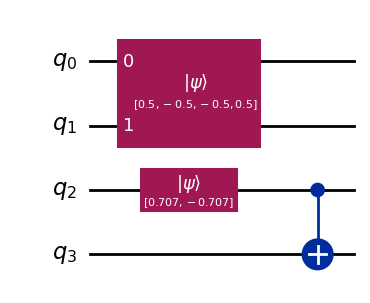

In [8]:
Circuit = QuantumCircuit(4)

Circuit.initialize([1/2,-1/2,-1/2,1/2],[0,1])
Circuit.initialize([1/np.sqrt(2),-1/np.sqrt(2)],2)
Circuit.cx(2,3)
Circuit.draw(output="mpl")

a) La probabilidad de medir 1 en cualquiera de los 4 qubits es 1/2. Esto se ve fácilmente evaluando los registros por separado (habida cuenta de que son inconexos)

En el primer registro de 2 qubits tenemos el estado:

$$|-\rangle|-\rangle = \frac{1}{2}(|00\rangle-|01\rangle-|10\rangle+|11\rangle)$$

De donde se ve que la probabilidad de medir un estado tal que el primer qubit sea 1 es la misma que la de que esto suceda para el qubit 2 y en ambos casos es 1/2.

En cuanto al segundo registro, el tercer qubit está en el estado $|-\rangle$, de modo que hay una probabilidad 1/2 de que dé 1 al medirlo. Por último, el cuarto qubit depende del tercero a través de un CNOT, de modo que tiene asimismo una probabilidad 1/2 de ser 1 (sujeta a la probabilidad de que el tercer qubit lo sea)

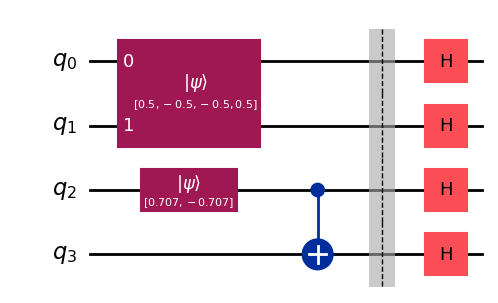

In [10]:
Circuit = QuantumCircuit(4)

Circuit.initialize([1/2,-1/2,-1/2,1/2],[0,1])
Circuit.initialize([1/np.sqrt(2),-1/np.sqrt(2)],2)
Circuit.cx(2,3)

Circuit.barrier()

for i in range(4):
    Circuit.h(i)

Circuit.draw(output="mpl")

- Se nos pregunta si la puerta CNOT puede alterar el qubit de control. La respuesta es que no, por definición de operación de control. A priori podría parecer que una operación controlada debe leer el estado del qubit control para saber qué asignar al qubit target, pero vemos que esto no sucede exactamente así, porque de lo contrario estaríamos colapsando el qubit control. Lo que pasa realmente es que, como el qubit control tiene cierta probabilidad de estar en un estado $|0\rangle$ y otra de estar en un estado $|1\rangle$, al qubit target se le asigna el estado $|1\rangle$ únicamente si resulta que el qubit 3 colapsa al estado $|1\rangle$. Si se quiere, esto es análogo a cómo funcionan las variables en runtime en computación clásica, cuyo valor se decide durante la ejecución del programa y no antes.

d) Explicado en c)

## Section 4.4

a) Construimos el circuito que se nos pide:

![](Circuit41.png)

b) Aplicamos ahora el circuito a la inversa sobre este circuito, y encontramos que, efectivamente, se recupera el estado inicial (todos los qubits inicializados a 0)

![](Circuit42.png)

c) Podemos construir una puerta SWAP con 3 puertas CNOT de la siguiente manera:

![](Circuit43.png)

- Cambiando los estados iniciales de los qubits, observo que esta construcción es válida en general

d) Podemos construir la permutación solicitada a partir de combinar múltiples trasposiciones (puertas SWAP). Como los ordenadores cuánticos actuales únicamente pueden ejecutar comandos de 2 qubits entre qubits aledaños, trataremos de buscar una combinación de trasposiciones que solo relacione vecinos más cercanos. Por ejemplo:

$$12345 \to 12435\to 21435 \to 24135$$

- El circuito cuántico correspondinte vendrá dado por:

![](Circuit44.png)

- Donde el último qubit no se muestra porque no se ve alterado. La permutación que se pide solo afecta a los 4 primeros qubits.

# Práctica 2

## Question: Why does the histogram have only one bar corresponding to $|1\rangle$?

**Respuesta:** porque así fue como preparamos nuestro sistema al inicializarlo con qc11.initialize(state_1,0), no había ninguna otra posibilidad.

## Question: Can you write in a piece of paper the initial state in the second line of the next paragraph?

**Respuesta:** $|\Psi\rangle = |\phi_1\rangle\otimes |\phi_2\rangle\otimes|\phi_3\rangle\otimes|\phi_4\rangle$

- con $|\phi_i\rangle =\frac{1}{\sqrt 2}(|0\rangle+|1\rangle)$

**Nota:** estrictamente, el resultado de la segunda linea no es un estado cuántico en tanto que no está normalizado, de modo que me he referido directamente a la tercera

## Question: run the circuit a few times and write down the binary number obtained 

**Respuesta:**

- Ejecutando el circuito con un número de shots $N=1$ cada vez, he obtenido:

Primera vez: 0110

Segunda vez: 0000

Tercera vez: 1100

##  Question: Write a loop that generates 32 random numbers and plot a histogram with their distribution 

**Trozo del código:**

In [ ]:
import matplotlib.pyplot as plt
results = []

for i in range(32):
    results.append(QRNG())
    
plt.hist(results)
plt.show()

**Código completo**

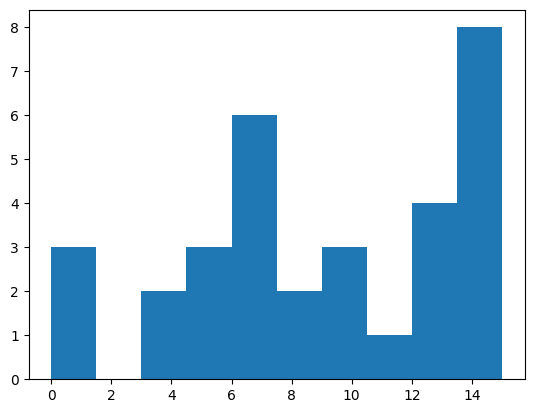

In [6]:
# A classical simulator of quantum circuits
from qiskit_aer import AerSimulator

# Class QuantumCircuit, with methods (functions) to define quantum circuits
from qiskit import QuantumCircuit

# A function yielding a histogram with the probabilities of each of the eigenstates taken by the measured qubits
from qiskit.visualization import plot_histogram

# Class Statvector, to retrieve the state of the circuit
from qiskit.quantum_info import Statevector

# Other usual functions
from math import sqrt, pi
import numpy as np

sim = AerSimulator()

def QRNG(): #a quantum random number generator
    qrng = QuantumCircuit(4,4) 
    init_state = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
    init_state_normal = init_state/np.linalg.norm(init_state)
    qrng.initialize(init_state_normal,[0,1,2,3]) 
    qrng.measure([0,1,2,3], [0,1,2,3]) 
    result = sim.run(qrng,shots=1).result()
    counts = result.get_counts(qrng)
    decimal_result = int(list(counts.keys())[0], 2)
    return decimal_result

import matplotlib.pyplot as plt
results = []

for i in range(32):
    results.append(QRNG())
    
plt.hist(results)
plt.show()

## Question: write down in a piece of paper all the methods that you have learned here 

1. Generación de números (binarios) aleatorios con un circuito cuántico
2. Simulación de sistemas de N qubits empleando qiskit y AER
3. Manipulación de dichos circuitos a través de puertas cuánticas
4. Construcción de puertas más complejas a partir de combinar puertas elementales

**Comentarios sobre el punto 1**

1. En esta segunda sesión, los números generados son pseudoaleatorios, como se puede comprobar fácilmente incrementando el número de eventos registrados en el hisotgrama, en lugar de considerar solo 32. Se observa que sale un patrón. Para la generación de números realmente aleatorios, se precisa de un ordenador cuántico de verdad, como el de IBM que se empleará en la sesión 3.

2. Con $N$ qubits, solo se pueden generar números (pseudo)aleatorios naturales menores que $2^N-1$. Si se quisieran generar números más grandes o pequeños, podría introducirse un factor de escala para los números obtenidos, pero el espaciado entre los nuevos números también se escalaría, de modo que no estaríamos consiguiendo un mayor número de dígitos aleatorios. El problema que veo con el método estudiado es que, ante la necesidad de generar números aleatorios, encuentro que siempre sería preferible trabajar con un generador suficientemente potente de números pseudoaleatorios, habida cuenta del alto coste y la fragilidad de la coherencia de un sistema de N qubits

3. Sería interesante estudiar una hibdridación entre la generación de números pseudoaleatorios clásica y la generación de números verdaderamente aleatorios con un ordenador cuántico, empleando el número generado por este último como semilla de los primeros y cambiando la semilla con suficiente frecuencia para evitar que aparezcan patrones.

## Question: Check that the following function implements the transformation

**Respuesta:** para comprobar si la puerta está correctamente implementada, podemos construir un circuito de 1 qubit donde este se encuentre en un estado de superposición tal que el refasaje sea observable. Si inicializamos dicho qubit al estado $|q\rangle=\frac{1}{\sqrt 2}(|0\rangle+|1\rangle)$ y actuamos sobre él $R(\pi)$, deberíamos obtener el estado $R|q\rangle=\frac{1}{\sqrt 2}(|0\rangle-|1\rangle)$

In [8]:
from qiskit.circuit.library import PhaseGate, XGate
def R(k):
    return PhaseGate((2.*np.pi)/pow(2,k))
    
A = QuantumCircuit(1)

A.initialize([1/np.sqrt(2), 1/np.sqrt(2)], 0)
A.append(R(1), [0])
A.draw(output="mpl")

phi = Statevector(A)
phi.data

array([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j])

Como esperábamos.

## Question: Write the state resulting from applying that transformation to the initial ket . Check, with the Statevector class that the circuit generates the correct output

- Haciendo la identificación $j_1=0,j_2=1,j_3=0$, deberíamos obtener el estado:

$$|010\rangle \to \frac{1}{\sqrt 2}(|0\rangle+e^{i\pi/2}|1\rangle)\otimes|10\rangle=\frac{1}{\sqrt 2}\begin{pmatrix}0\\0\\1\\0\\0\\0\\i\\0\end{pmatrix}$$

- Veamos si obtenemos este estado aplicando el circuito al estado inicial

In [9]:
qft_circuit_1 = QuantumCircuit(3, name = 'QFT')

state0 = [1,0]
state1 = [0,1]

qft_circuit_1.initialize(state0, 0)
qft_circuit_1.initialize(state1, 1)
qft_circuit_1.initialize(state0, 2)

qft_circuit_1.h(2)

qft_circuit_1.append(R(2).control(),[2,1]) 
qft_circuit_1.draw(output='mpl')

state = Statevector(qft_circuit_1)
print(list(state))

[np.complex128(0j), np.complex128(0j), np.complex128(0.7071067811865475+0j), np.complex128(0j), np.complex128(0j), np.complex128(0j), np.complex128(4.329780281177466e-17+0.7071067811865475j), np.complex128(0j)]


- Que coincide con el estado calculado

## 5.3 QFT full exercise

**Please implement now the Quantum Fourier Transform as a gate acting over 5 qubits.  Apply this gate to the following states:**

$$ |\phi_1\rangle = \frac{1}{2^{5/2}}\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle-\left|1\right\rangle\right)$$
$$ |\phi_2\rangle = \frac{1}{2^{5/2}}\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle-\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)$$
$$ |\phi_3\rangle = \frac{1}{2^{5/2}}\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle-\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)$$
$$ |\phi_4\rangle = \frac{1}{2^{5/2}}\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle-\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)\left(\left|0\right\rangle+\left|1\right\rangle\right)$$

**Briefly comment on the results.**

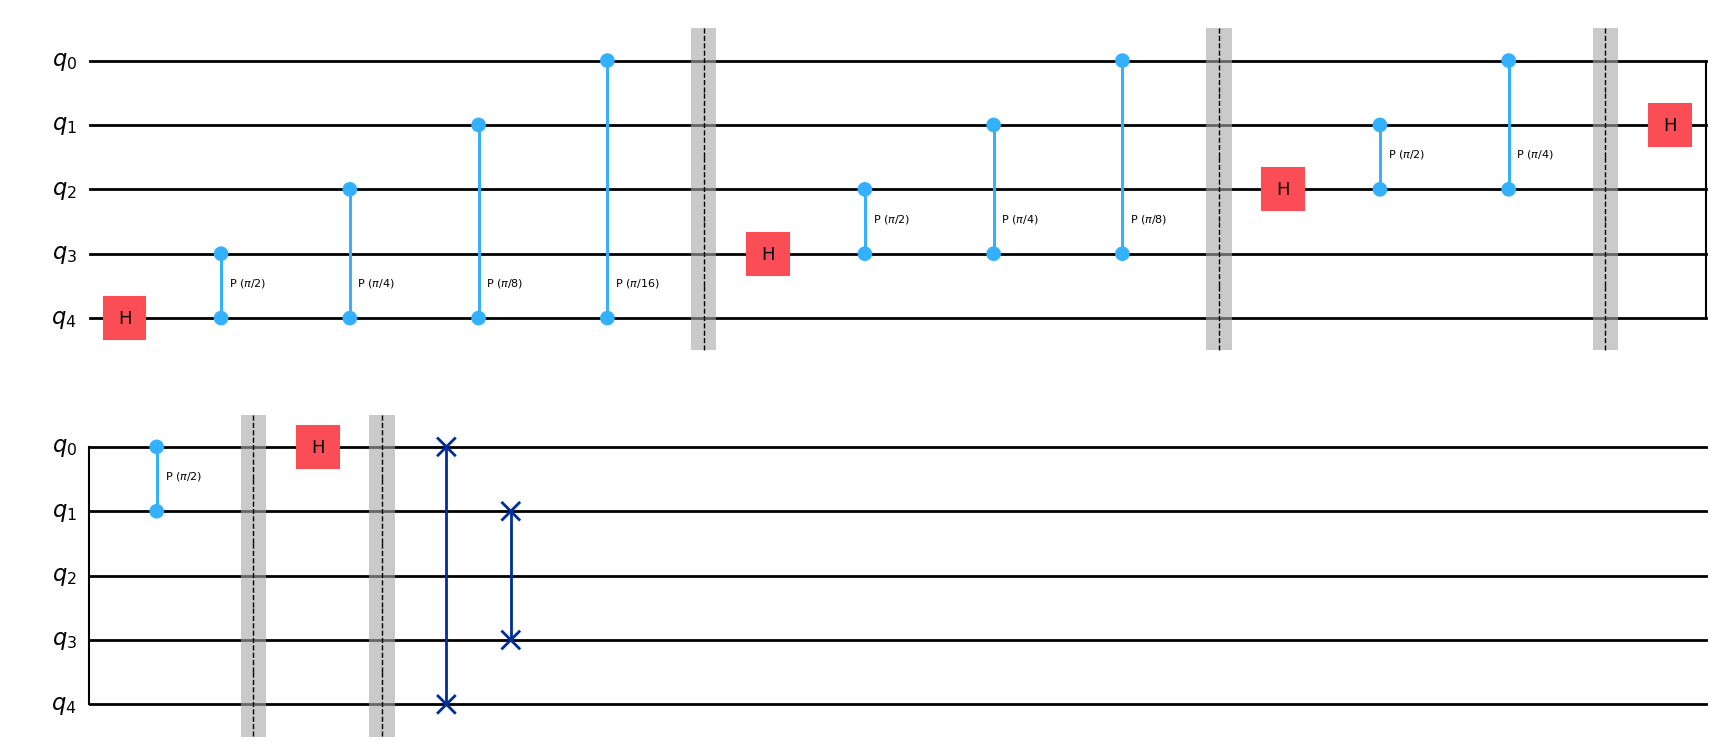

In [10]:
qft5 = QuantumCircuit(5, name = 'QFT3')

qft5.h(4)
qft5.append(R(2).control(),[4,3])
qft5.append(R(3).control(),[4,2])
qft5.append(R(4).control(),[4,1])
qft5.append(R(5).control(),[4,0])
qft5.barrier()

qft5.h(3)
qft5.append(R(2).control(),[3,2])
qft5.append(R(3).control(),[3,1])
qft5.append(R(4).control(),[3,0])
qft5.barrier()

qft5.h(2)
qft5.append(R(2).control(),[2,1])
qft5.append(R(3).control(),[2,0])
qft5.barrier()

qft5.h(1)
qft5.append(R(2).control(),[1,0])
qft5.barrier()

qft5.h(0)
qft5.barrier()

# SWAP
qft5.swap(4,0)
qft5.swap(1,3)

qft5.draw(output='mpl')

- Quitamos la el método barrier() para poder transformar este circuito a una puerta

In [11]:
qft5 = QuantumCircuit(5, name = 'QFT3')

qft5.h(4)
qft5.append(R(2).control(),[4,3])
qft5.append(R(3).control(),[4,2])
qft5.append(R(4).control(),[4,1])
qft5.append(R(5).control(),[4,0])

qft5.h(3)
qft5.append(R(2).control(),[3,2])
qft5.append(R(3).control(),[3,1])
qft5.append(R(4).control(),[3,0])

qft5.h(2)
qft5.append(R(2).control(),[2,1])
qft5.append(R(3).control(),[2,0])

qft5.h(1)
qft5.append(R(2).control(),[1,0])

qft5.h(0)

# SWAP
qft5.swap(4,0)
qft5.swap(1,3)

In [12]:
# Building gate
qft5 = qft5.to_gate()

In [13]:
# These are the initial states of the single qubits

state_p = 1/np.sqrt(2)*np.array([1,1])
state_m = 1/np.sqrt(2)*np.array([1,-1])

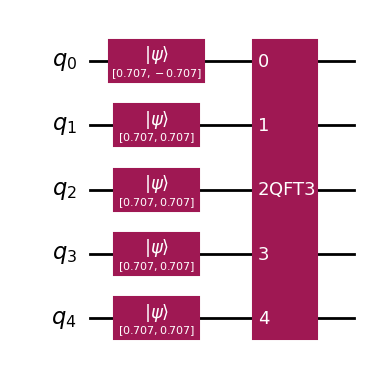

In [14]:
# State 1:
Ex5_1 = QuantumCircuit(5)

Ex5_1.initialize(state_m, 0)
Ex5_1.initialize(state_p, 1)
Ex5_1.initialize(state_p, 2)
Ex5_1.initialize(state_p, 3)
Ex5_1.initialize(state_p, 4)

Ex5_1.append(qft5, [0,1,2,3,4])

Ex5_1.draw(output="mpl")

In [15]:
phi1 = Statevector(Ex5_1)
phi1.data[phi1.data < 1e-10]=0

print(f"Nonzero at position(s): {np.where(np.abs(phi1.data)!=0)} with value(s) {phi1.data[np.where(np.abs(phi1.data)!=0)]}")

Nonzero at position(s): (array([16]),) with value(s) [1.+0.j]


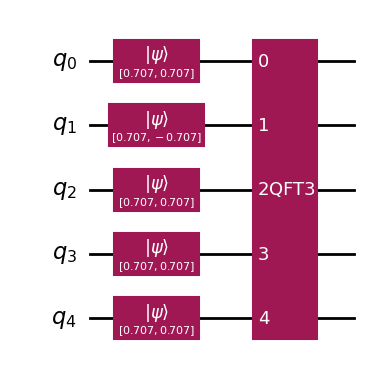

In [16]:
# State 2:
Ex5_2 = QuantumCircuit(5)

Ex5_2.initialize(state_p, 0)
Ex5_2.initialize(state_m, 1)
Ex5_2.initialize(state_p, 2)
Ex5_2.initialize(state_p, 3)
Ex5_2.initialize(state_p, 4)

Ex5_2.append(qft5, [0,1,2,3,4])

Ex5_2.draw(output="mpl")

In [17]:
phi2 = Statevector(Ex5_2)
phi2.data[phi2.data < 1e-10]=0

print(f"Nonzero at position(s): {np.where(np.abs(phi2.data)!=0)} with value(s) {phi2.data[np.where(np.abs(phi2.data)!=0)]}")

Nonzero at position(s): (array([ 8, 24]),) with value(s) [0.5+0.5j 0.5-0.5j]


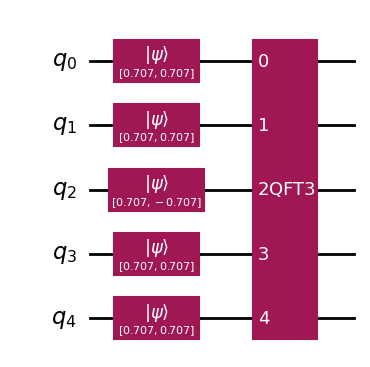

In [18]:
# State 3:
Ex5_3 = QuantumCircuit(5)

Ex5_3.initialize(state_p, 0)
Ex5_3.initialize(state_p, 1)
Ex5_3.initialize(state_m, 2)
Ex5_3.initialize(state_p, 3)
Ex5_3.initialize(state_p, 4)

Ex5_3.append(qft5, [0,1,2,3,4])

Ex5_3.draw(output="mpl")

In [19]:
phi3 = Statevector(Ex5_3)
phi3.data[phi3.data < 1e-10]=0

print(f"Nonzero at position(s): {np.where(np.abs(phi3.data)!=0)} with value(s) {phi3.data[np.where(np.abs(phi3.data)!=0)]}")

Nonzero at position(s): (array([ 4, 12, 20, 28]),) with value(s) [0.25+0.60355339j 0.25+0.10355339j 0.25-0.10355339j 0.25-0.60355339j]


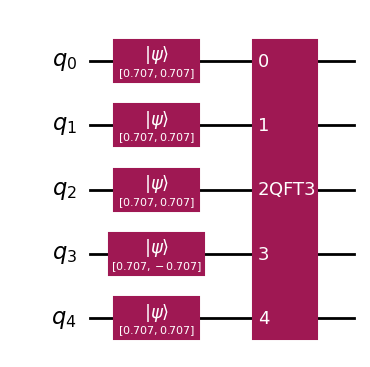

In [20]:
# State 4:
Ex5_4 = QuantumCircuit(5)

Ex5_4.initialize(state_p, 0)
Ex5_4.initialize(state_p, 1)
Ex5_4.initialize(state_p, 2)
Ex5_4.initialize(state_m, 3)
Ex5_4.initialize(state_p, 4)

Ex5_4.append(qft5, [0,1,2,3,4])

Ex5_4.draw(output="mpl")

In [21]:
phi4 = Statevector(Ex5_4)
phi4.data[phi4.data < 1e-10]=0

print(f"Nonzero at position(s): {np.where(np.abs(phi4.data)!=0)} with value(s) {phi4.data[np.where(np.abs(phi4.data)!=0)]}")

Nonzero at position(s): (array([ 2,  6, 10, 14, 18, 22, 26, 30]),) with value(s) [0.125+0.62841744j 0.125+0.18707572j 0.125+0.08352233j 0.125+0.02486405j
 0.125-0.02486405j 0.125-0.08352233j 0.125-0.18707572j 0.125-0.62841744j]


- Para el primer estado, obtenemos un único dígito, de igual forma que en el ejemplo con 3 qubits obteníamos un 4. Sin embargo, este no es el caso para el resto de vectores de estado, que dan estados finales más complicados tras ser sometidos al QFT. Es interesante notar que el QFT es sensible a las permutaciones de qubits, resultado que no debería sorprender demasiado habida cuenta de que el propio producto tensorial es bilineal pero no conmutativo. 

# Práctica 3.1: Random numbers

In [2]:
# PREAMBLE 
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options

## Question 1: Define the circuit already known from session 2 with qiskit commands

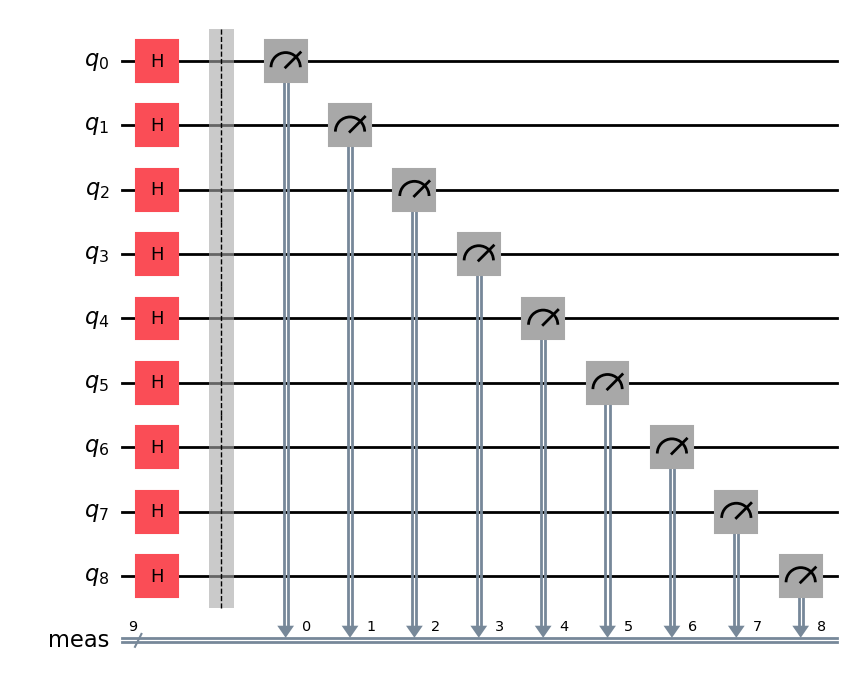

In [3]:
#How many random numbers will be produced in a single shot:
Nnumbers=3  #must be smaller than [127 qubits/3]=42
# Prepare the input circuit.
QRNG = QuantumCircuit(3*Nnumbers) #four qubits
for j in range(Nnumbers):
  QRNG.h([(3*j+0),(3*j+1),(3*j+2)]) #apply Hadamard gate to each of the qubits

QRNG.measure_all() #measure all qubits
QRNG.draw(output="mpl") #plot circuit: don't do it with many qubits

# Question 2: Comment on your results 

- Antes de comentar los resultados de esta práctica, encuentro pertinente adjuntar el código que he empleado para la generación de números verdaderamente aleatorios entre 0 y 7

In [4]:
My_user_token = "97e7db9f2518e2fe002b974e6c25b4c972fc2256dd5661db1cf0feabfe9b857be7730294d9e943202198db999b43ecf31f144e8212858957d0ad040401e2f4f0" 
# Quantum machine
Quantum_service = QiskitRuntimeService(channel="ibm_quantum",token=My_user_token)
Quantum_service.usage()
backend_Q = Quantum_service.least_busy(operational=True, simulator=False, min_num_qubits=3*Nnumbers)
# Create the options object with attributes and values
options = {"max_execution_time": 30} #maximum number of seconds that we allow this to run
# Number of shots (repetitions of the job)
shots_Q=1
sampler = Sampler(mode=backend_Q,options=options) #to specify that we are going to make a sampling of the measurement

# Execute the circuit
job = sampler.run([transpile(QRNG,backend_Q)],shots=shots_Q)

In [6]:
job.status()

'DONE'

In [7]:
result = job.result()[0].data.meas.get_counts()
result.keys()

Auxnumberlist = list(result.keys())
Auxnumber=int(Auxnumberlist[0])  #now we have isolated the number
aux = Auxnumber
Listofrandomnumbers = []  #empty list which will contain the random numbers

while aux>8:  #when the condition fails, aux will be the last of the random numbers
    quotientremainder = divmod(aux,8) #while the condition is true, the remainder is the next random number
    # Alternative not using the built-in divmod function
    # newnumber = aux % 8 #remainder of dividing by 8 so we extract three bits from aux
    # aux = aux//8  #division without remainder
    newnumber = quotientremainder[1]
    aux = quotientremainder[0]
    Listofrandomnumbers.append(newnumber) # we put them in a list
Listofrandomnumbers.append(aux) #append the last one and finish

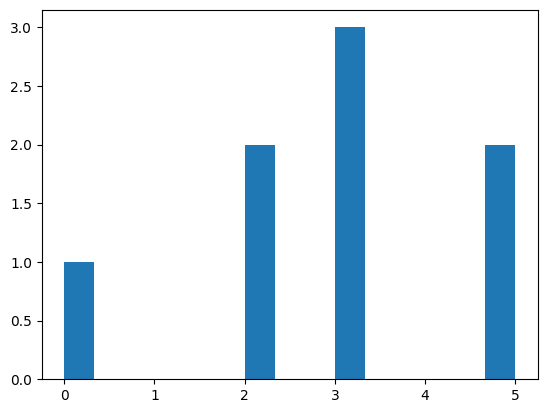

In [8]:
from matplotlib import pyplot as plt
plt.hist(Listofrandomnumbers, 15)
plt.show()

- Estrictamente, no podemos extraer ninguna conclusión sobre si los números obtenidos son realmente aleatorios o no, habida cuenta de que el espacio muestral es demasiado pequeño. No obstante, si generásemos una mayor cantidad de números, deberíamos ser capaces de obtener una distribución equiprobable (esto se deduce de la preparación del estado inicial).

# Práctica 3.2: Algoritmo de Deutsch

In [1]:
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import Aer
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp, Operator
import numpy as np
from numpy import sqrt as sqrt

# Number of shots (repetitions of the program)
shots_S=100 #simulation()

# Simulator backend
sim = Aer.get_backend('aer_simulator') 

Oracle_f = Operator([[0,0,1,0],[0,1,0,0],[1,0,0,0],[0,0,0,1]])
Oracle_g = Operator([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])

## Homework 1 (to do later after the lab on pen and paper): Prove that this is a unitary operation.

![Dem1](Dem11.jpg)

![Dem12](Dem12.jpg)

##  Question 2: Complete the following cells to create quantum circuits for Oracle_f that decides whether $f$ is (or not) constant using the classical method with two evaluations

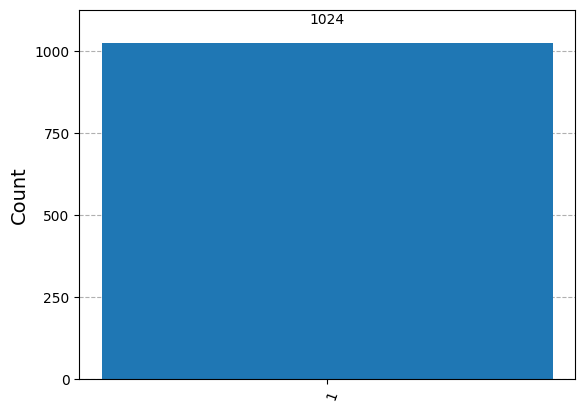

In [4]:
#Classical check Oracle_f: f(0)
Check_f0 = QuantumCircuit(2,1)
#Remember that by default the two qubits are initialized to zero
Check_f0.unitary(Oracle_f, [0, 1],label="Oracle_f")  # Apply Oracle_f
# Measure qubit 1

Check_f0.measure(1,0)

resultmeasure = sim.run(Check_f0).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts)

$$\boxed{f(0)=1}$$

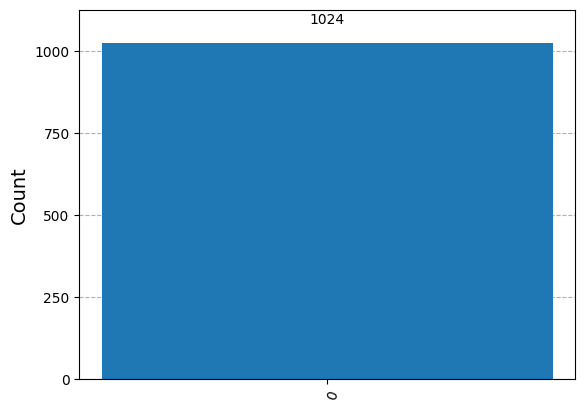

In [5]:
##Classical check Oracle_f: f(1)
Check_f1 = QuantumCircuit(2,1)
#We initialize the first qubit to 1:
Check_f1.x(1)

Check_f1.unitary(Oracle_f, [0,1],label="Oracle_f")  # Apply Oracle_f
# Measure qubit 1

Check_f1.measure(0,0)

Check_f1.draw(output="mpl")

resultmeasure = sim.run(Check_f1).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts)

$$\boxed{f(1)=0}$$

**Conclusión con método clásico + circuito simulado:** $f$ no es constante (en el 100% de los casos)

### Run the quantum circuits on a classical computer (the simulation machine) to obtain the values of $f(0)$ and $f(1)$

- Ya está hecho en los dos apartados superiores. Con todo, se adjunta el código

In [6]:
# One shot for each circuit
shots_C=1
# Sampler with aer simulator as backend
sampler_S = Sampler(mode=sim);
# The sampler evaluates probabilities of each input circuit
jobs_f = sampler_S.run([Check_f0,Check_f1],shots=shots_C).result();
result_f_0 = jobs_f[0].data.c.get_counts() # result of Check_f0 circuit
result_f_1 = jobs_f[1].data.c.get_counts() # result of Check_f1 circuit

## Question 3: By printing "result_f_0" and "result_f_1", explain why the following cell gives the calculated result for $f(0)$ and $f(1)$

In [7]:
#Print the measurement results
print(f"f(0)={max(result_f_0)}") 
print(f"f(1)={max(result_f_1)}")

f(0)=1
f(1)=0


- Naturalmente, obtenemos el mismo resultado que en la sección anterior. Es suficiente con poner una medida al final del circuito para medir el estado final del segundo ket

## Question 4: Complete the following cells to create quantum circuits for Oracle_g that solve the problem for using the classical method of two evaluations 

- Repetimos la sección anterior, ahora para $g$

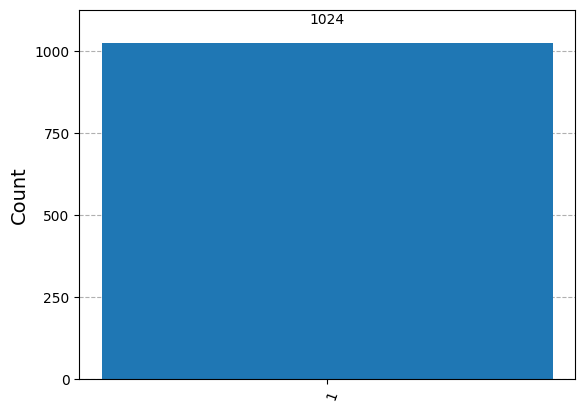

In [8]:
#Classical check Oracle_g: g(0)
Check_g0 = QuantumCircuit(2,1)
#Remember that by default the two qubits are initialized to zero
Check_g0.unitary(Oracle_g, [0, 1],label="Oracle_g")  # Apply Oracle_f
# Measure qubit 1

Check_g0.measure(1,0)

resultmeasure = sim.run(Check_g0).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts)

$$\boxed{g(0)=1}$$

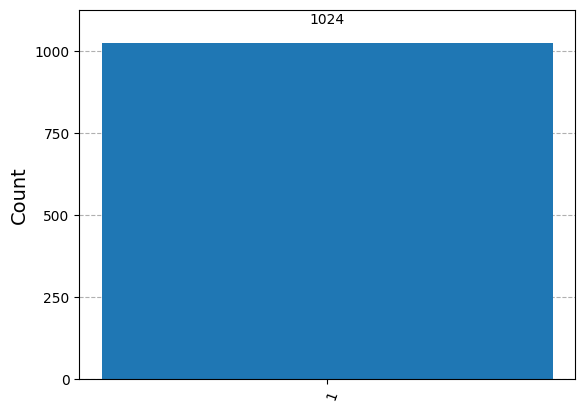

In [9]:
#Classical check Oracle_g: f(1)
Check_g1 = QuantumCircuit(2,1)
#Remember that by default the two qubits are initialized to zero
Check_g1.unitary(Oracle_g, [1,0],label="Oracle_g")  # Apply Oracle_g
# Measure qubit 1

Check_g1.measure(0,0)

resultmeasure = sim.run(Check_g0).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts)

$$\boxed{g(1)=1}$$

### Run the quantum circuits on a classical computer (the simulation machine) to obtain the values of $g(0)$ and $g(1)$

In [10]:
jobs_g = sampler_S.run([Check_g0,Check_g1],shots=shots_S);
result_g_0 = jobs_g.result()[0].data.c.get_counts()
result_g_1 = jobs_g.result()[1].data.c.get_counts()

In [11]:
#Print the measurement results
print(f"g(0)={max(result_g_0)}")
print(f"g(1)={max(result_g_1)}")

g(0)=1
g(1)=1


## Homework question 5: Prove (after the lab, on pen and paper):

if $f(0)\neq f(1)$, the final state becomes: 
    
$$
|-\rangle \left[\frac{|f(0)\rangle-|f(1)\rangle}{\sqrt{2}}\right].
$$ 

![Dem2](Dem25.png)

## Question 6: Define a quantum circuit to implement Deutsch's algorithm with the function $f$ and another with the function $g$

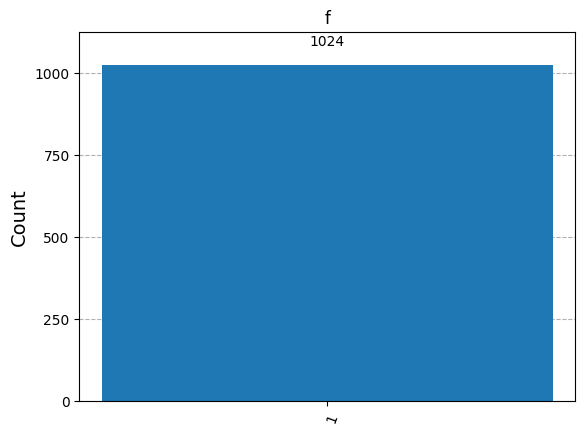

In [2]:
# Deutsch's for f
deutsch_f = QuantumCircuit(2,1)
deutsch_f.x(1)  # Apply X gate to qubit 0
deutsch_f.h([0, 1])  # Apply Hadamard gate to both qubits

# Ahora tengo estado inicial |+->

deutsch_f.unitary(Oracle_f, [0, 1],label="Oracle_f")  # Apply Oracle_f
deutsch_f.h(0)  # Apply Hadamard gate to qubit 0

# Measure qubit 0

deutsch_f.measure(0,0)

resultmeasure = sim.run(deutsch_f).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts, title="f")

**Conclusión:** $f$ no es constante

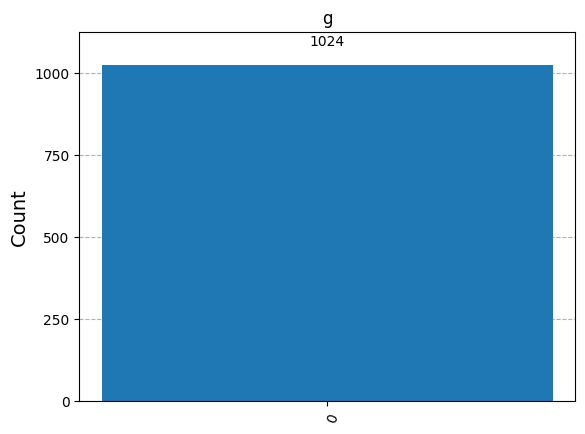

In [13]:
# Deutsch's for g
deutsch_g = QuantumCircuit(2,1)
deutsch_g.x(1)  # Apply X gate to qubit 0
deutsch_g.h([0, 1])  # Apply Hadamard gate to both qubits

# Ahora tengo estado inicial |+->

deutsch_g.unitary(Oracle_g, [0, 1],label="Oracle_g")  # Apply Oracle_f
deutsch_g.h(0)  # Apply Hadamard gate to qubit 0

# Measure qubit 0

deutsch_g.measure(0,0)

resultmeasure = sim.run(deutsch_g).result() # Execute the circuite qc11 in the simulator

counts = resultmeasure.get_counts() # Results of the measurements
plot_histogram(counts, title="g")

**Conclusión:** $g$ es constante

### Let us execute these circuits on a free simulator

In [13]:
# Execute the circuit 
jobs_DeutschS=sampler_S.run([deutsch_f,deutsch_g],shots=shots_S).result() # one entry for each function

In [14]:
result_DeutschS_f = jobs_DeutschS[0].data.c.get_counts()
result_DeutschS_g = jobs_DeutschS[1].data.c.get_counts()

In [15]:
# Print the measurement results for f, if 0 the fuction is constant
if max(result_DeutschS_f)=='0':
    print("f is constant")
else:
    print("f is not constant")


f is not constant


In [17]:
# Print the measurement results for g, if 0 the fuction is constant
if max(result_DeutschS_g)=='0':
    print("g is constant")
else:
    print("g is not constant")

g is constant


### Run the quantum circuits on a real quantum machine

In [14]:
My_user_token = "97e7db9f2518e2fe002b974e6c25b4c972fc2256dd5661db1cf0feabfe9b857be7730294d9e943202198db999b43ecf31f144e8212858957d0ad040401e2f4f0" # Use this at home (long waiting time
# Quantum machine
Quantum_service = QiskitRuntimeService(channel="ibm_quantum",token=My_user_token)
backend_Q = Quantum_service.least_busy(operational=True, simulator=False, min_num_qubits=100)

In [15]:
shots_Q=3
sampler_Q = Sampler(mode=backend_Q) #to obtain the sampling of the measurement 
# Execute the circuit 
job_Q=sampler_Q.run([transpile(deutsch_f,backend_Q),transpile(deutsch_g,backend_Q)],shots=shots_Q)

In [29]:
job_Q.status()

'DONE'

In [30]:
job_number = job_Q.job_id()
job =  Quantum_service.job(job_number)
result = job.result()

In [31]:
# Print the measurement results for f, if 0 the fuction is constant
if max(result[0].data.c.get_counts())=='0':
    print("f is constant")
else:
    print("f is not constant")

f is not constant


In [32]:
# Print the measurement results for g, if 0 the fuction is constant
if max(result[1].data.c.get_counts())=='0':
    print("g is constant")
else:
    print("g is not constant")

g is constant


##  Question 7: Does the result of your quantum computation using Deutsch's algorithm agree with the previous classical result?

- Sí, el resultado del algoritmo clásico y el del cuántico coinciden. Esto era de esperar, habida cuenta de que la única diferencia entre el algoritmo clásico y el cuántico es que en este último nos estamos aprovechando del principio de superposición para ejecutar operaciones simultáneamente sobre varios qubits. No obstante, aparte de esto, el tratamiento de los propios qubits sigue siendo enteramente clásico (i.e: la suma de dos bits módulo 2), de modo que era de esperar que nuestro resultado fuera correcto y que el veredicto sobre el carácter constante o variable de las funciones $f$ y $g$ fuera siempre el mismo independientemente del número de shots que se tomaran.

# Práctica 3.3: Desigualdad CHSH

In [2]:
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer # Aer simulator
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from numpy import sqrt as sqrt
np.set_printoptions(precision=7)

# Loading the aer simulator
backend_S = Aer.get_backend("aer_simulator")

## Question 2: Using this command, define the four product observables that appear in the CHSH inequality: $A_1B_1$, $A_2B_1$, $A_1B_2$, and $A_2B_2$

In [3]:
# Define pairs of observables for maximum violation of the CHSH innequality
A1B1=SparsePauliOp.from_list([('XX', -1/sqrt(2)), ('XY', -1/sqrt(2))])
A1B2=SparsePauliOp.from_list([('XX', -1/sqrt(2)), ('XY', +1/sqrt(2))])
A2B1=SparsePauliOp.from_list([('YX', -1/sqrt(2)), ('YY', -1/sqrt(2))])
A2B2=SparsePauliOp.from_list([('YX', -1/sqrt(2)), ('YY', +1/sqrt(2))])
Obs=[A1B1,A1B2,A2B1,A2B2] #The four correlators are packaged in one list of observables

## Question 1:  Define a circuit that prepares the "singlet state" of two qubits $|\Psi^-\rangle=\tfrac{1}{\sqrt2}(|01\rangle-|10\rangle)$

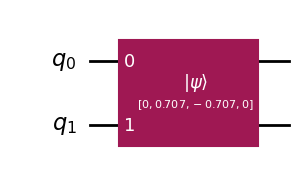

In [4]:
# Prepare the input circuit:
import numpy as np

chsh_circuit = QuantumCircuit(2)
chsh_circuit.initialize([0,1/np.sqrt(2),-1/np.sqrt(2),0],[0,1])

chsh_circuit.draw(output="mpl")

### Run the quantum circuit on the simulation machine

In [34]:
# Choose the "backend" (computational engine doing the work behind)  
estimator_S = Estimator(mode=backend_S) #for the determination of mean values

# Execute the circuit 
job_S = estimator_S.run([(chsh_circuit,Obs)])
result_S = job_S.result()[0]

In [35]:
#Print simulated expectation values
print(f"Simulated expectation values for the four correlators:\n  {result_S.data.evs}")

Simulated expectation values for the four correlators:
  [ 0.7185006  0.695713   0.7174648 -0.6967488]


In [36]:
# Retrieve sample variance and number of shots from metadata
StandardDeviations = result_S.data.stds
std_S1=round(StandardDeviations[0],3)
std_S2=round(StandardDeviations[1],3)
std_S3=round(StandardDeviations[2],3)
std_S4=round(StandardDeviations[3],9) #note the different rounding off here, for checking


# Calculate and print simulated standard errors
Standard_errors_S = [float(std_S1),float(std_S2),float(std_S3),float(std_S4)]
print(f"Simulated standard errors: {Standard_errors_S}")

Simulated standard errors: [0.011, 0.011, 0.011, 0.011047358]


## Question 3: Calculate the simulated value obtained for the CHSH inequality jointly with its error 

In [37]:
vals = result_S.data.evs

CHSH_mean = np.abs(vals[0]+vals[1]+vals[2]-vals[3])
CHSH_uncertainty = np.sqrt(np.sum(np.array(Standard_errors_S)**2))
print(f"The simulated result is {CHSH_mean} + {CHSH_uncertainty}:\ndoes it exceed 2 with sufficient statistical certainty?")

The simulated result is 2.82842712474619 + 0.02202371718807168:
does it exceed 2 with sufficient statistical certainty?


**Nota:** vemos que la simulación predice que, efectivamente, se viola la desiguldad clásica con suficiente confianza

### Run the quantum circuit on a real quantum machine

In [5]:
My_user_token = "97e7db9f2518e2fe002b974e6c25b4c972fc2256dd5661db1cf0feabfe9b857be7730294d9e943202198db999b43ecf31f144e8212858957d0ad040401e2f4f0" # Use this at home (long waiting time
# Quantum machine
Quantum_service = QiskitRuntimeService(channel="ibm_quantum",token=My_user_token)
Quantum_service.usage()
backend_Q = Quantum_service.least_busy(operational=True, simulator=False, min_num_qubits=20)

# Maximum execution time in seconds
my_options = {"max_execution_time": 20}
# Number of shots
pm = generate_preset_pass_manager(backend=backend_Q, optimization_level=1) #Define pass manager
CHSH_circuits = pm.run(chsh_circuit) #copy the circuit 4 times and run against the pass manager
CHSH_observables = [ob.apply_layout(CHSH_circuits.layout) for ob in Obs] #apply transpiled circuit layout to observables
estimator_Q = Estimator(mode=backend_Q,options=my_options) #for the determination of mean values
# Execute the circuit 
job_Q = estimator_Q.run([(CHSH_circuits, CHSH_observables)])

In [9]:
job_Q.status()

'DONE'

In [10]:
result_Q = job_Q.result()[0]
#Once the program has run we can print the simulated expectation values
print(f"Expectation values: {result_Q.data.evs}")

# Retrieve sample variance and number of shots from metadata
StandardDeviations = result_Q.data.stds
std_Q1=round(StandardDeviations[0],3)
std_Q2=round(StandardDeviations[1],3)
std_Q3=round(StandardDeviations[2],3)
std_Q4=round(StandardDeviations[3],9)
# Calculate and print standard errors
Standard_errors_Q = [float(std_Q1),float(std_Q2),float(std_Q3),float(std_Q4)]
print(f"Standard errors: {Standard_errors_Q}")

Expectation values: [ 0.7308677  0.7572473  0.7021606 -0.7106952]
Standard errors: [0.014, 0.014, 0.014, 0.013696298]


## Question 4: Compute, with a hand calculator or simple python commands, the experimental value obtained for the CHSH inequality jointly with its error from the quantum data obtained

In [11]:
vals_Q = result_Q.data.evs

CHSH_mean_Q = [vals_Q[0]+vals_Q[1]+vals_Q[2]-vals_Q[3]]
CHSH_uncertainty_Q = np.sqrt(np.sum(np.array(Standard_errors_Q)**2))
print(f"The experimental result is {CHSH_mean_Q} + {CHSH_uncertainty_Q}:\ndoes it exceed 2 with sufficient statistical certainty?")

The experimental result is [np.float64(2.9009707912291876)] + 0.027849390997018303:
does it exceed 2 with sufficient statistical certainty?


**Nota:** observamos que, efectivamente, la desigualdad de Bell se viola, de modo que la realidad es no local, tal y como predecía nuestra simulación.